# Canopy gap dynamics from repeated airborne laser scanning — Ducke site, Brazilian Amazon

Reproduction of the gap-dynamics analysis of **"Tracking canopy gap dynamics across four sites in the Brazilian Amazon"** (bioRxiv 2022.09.03.506473; journal version in *Biotropica*, doi:10.1111/btp.13226), from the authors' repository [`Gorgens/dynamics-gap`](https://github.com/Gorgens/dynamics-gap) pinned at commit `aae2888511781baba3c7a42404ebcf4c731d6a4e` (GPL-3.0).

**Scope (partial demonstration, one site).** This notebook reproduces, for the **Ducke** site only (1,205 ha; ALS flights 2017 and 2020):
1. gap frequency/size-class tables (author script `03 frequency table gap.R` logic),
2. the chi-squared test of gap-size distributions between flights (author script `01 chi squared gap distribution.R` logic, Ducke subset),
3. the gap state-transition matrix with new-gap marking (author script `04 transition matrix gaps.R` logic).

Not reproduced: the other three sites, the raw ALS→CHM→gap pipeline (`00-*.R`, requires multi-GB point clouds), raster height-rate analysis, and full-paper tables.

**AI-assisted adaptation notice / 注意.** The authors did not provide this Colab implementation; it is an AI-assisted adaptation of the authors' pinned R code (`rgdal`/`raster`/`pivottabler` are retired/unavailable on current CRAN, so shapefile attributes are read with `geopandas` and the author's dplyr/`chisq.test` logic runs in R via `Rscript`). The executed example and listed checks were validated, but untested behavior is not guaranteed. / 本ノートブックは著者提供のColab実装ではなく、AIが著者のRコードを最小限修正して移植したものです。実行済みの例と検証結果は本実行によるものであり、未検証の動作は保証されません。

**Execution status: executed in Colab (CPU).** See the validation record at the end.

## Runtime selection / ランタイム選択

**Select `Runtime > Change runtime type > CPU (standard)` and then `Runtime > Run all`.** / 「ランタイム」→「ランタイムのタイプを変更」で **CPU** を選択し、「すべてのセルを実行」してください。

No GPU is used anywhere in this analysis (tabular/vector statistics only), so CPU is the recommended (and only needed) runtime. Expected end-to-end time ≈ 10–15 min: apt/R setup ~3–6 min, downloads ~55 MB of author-shipped gap shapefiles plus R packages, analysis <1 min. All data files are downloaded here, inside Colab.

In [ ]:
import shutil, subprocess, sys, os, platform

print("Python:", sys.version.split()[0], "on", platform.machine())
print("CPUs:", os.cpu_count())
rscript = shutil.which("Rscript")
print("Rscript found:", rscript)
for d in ("/content/data", "/content/r"):
    os.makedirs(d, exist_ok=True)
print("work dirs ready:", os.listdir("/content"))

Python: 3.13.15 on x86_64
CPUs: 2
Rscript found: /usr/bin/Rscript
work dirs ready: ['.config', 'r', 'data', 'sample_data']


## Environment setup / 環境構築

Installs the R runtime (author code is R; we run the author's statistical logic with `Rscript`) and `geopandas` for reading the author-shipped shapefiles. The original scripts depend on `rgdal`/`rgeos`, which CRAN retired in October 2023, so shapefile I/O moved to `geopandas`/`pyogrio`; see the mapping table before the analysis cells.

R の実行環境（`r-base-core`）と shapefile 読み取り用の `geopandas` をインストールします。

In [ ]:
import subprocess, sys

print("[1/2] apt: installing r-base-core (quiet) ...", flush=True)
subprocess.run(["apt-get", "update", "-qq"], check=True, timeout=300)
subprocess.run(["apt-get", "install", "-y", "-qq", "r-base-core"], check=True, timeout=900)
print("[2/2] pip: geopandas + pyogrio ...", flush=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "geopandas", "pyogrio"], check=True, timeout=600)
print("setup done", flush=True)

[1/2] apt: installing r-base-core (quiet) ...


[2/2] pip: geopandas + pyogrio ...


setup done


### R package installation

Only pure-R CRAN packages are needed for the author's statistics: `dplyr`/`tidyr` (grouped summaries and pivots) and `ggplot2` (notebook-added plot). The author's `pivottabler` call is equivalent to a grouped sum (mapping documented below), so that package is not required.

R パッケージ（`dplyr`, `tidyr`, `ggplot2`）を CRAN からインストールします。

In [ ]:
import subprocess

code = ('options(warn=1); install.packages(c("dplyr","tidyr","ggplot2"), '
        'repos="https://cloud.r-project.org", quiet=TRUE); '
        'ip <- rownames(installed.packages()); '
        'cat("R:", R.version.string, "\\n"); '
        'cat("installed:", paste(intersect(c("dplyr","tidyr","ggplot2"), ip), collapse=", "), "\\n")')
print("installing R packages (a few minutes) ...", flush=True)
subprocess.run(["Rscript", "-e", code], check=True, timeout=1500)
print("R packages ready", flush=True)

installing R packages (a few minutes) ...


R packages ready


## Minimal input acquisition / 最小入力データの取得

Downloads only the three Ducke layers shipped by the authors in the pinned repository (`vector-based/data/`), from `raw.githubusercontent.com` at commit `aae2888511781baba3c7a42404ebcf4c731d6a4e`:

| layer | role | files |
| --- | --- | --- |
| `ducke_2017gapsClean` | gap polygons, flight 1 (2017) | .shp/.dbf/.shx/.prj |
| `ducke_2020gapsClean` | gap polygons, flight 2 (2020) | .shp/.dbf/.shx/.prj |
| `ducke_overlay` | polygonized overlay of both flights with transition attributes | .shp/.dbf/.shx/.prj |

Each file is validated: HTTP status, size, SHA-256, and shapefile/DBF magic bytes (error HTML is rejected). / 著者リポジトリ（固定コミット）からDuckeの3レイヤーのみダウンロードし、サイズ・SHA-256・シグネチャを検証します。

In [ ]:
import hashlib, json, requests

COMMIT = "aae2888511781baba3c7a42404ebcf4c731d6a4e"
BASE = f"https://raw.githubusercontent.com/Gorgens/dynamics-gap/{COMMIT}/vector-based/data/"
FILES = {  # name -> expected size in bytes (GitHub tree metadata, commit aae2888)
    "ducke_2017gapsClean.shp": 10542468, "ducke_2017gapsClean.dbf": 831881,
    "ducke_2017gapsClean.shx": 50892,    "ducke_2017gapsClean.prj": 415,
    "ducke_2020gapsClean.shp": 6683364,  "ducke_2020gapsClean.dbf": 581671,
    "ducke_2020gapsClean.shx": 35612,    "ducke_2020gapsClean.prj": 415,
    "ducke_overlay.shp": 24485648,       "ducke_overlay.dbf": 11929634,
    "ducke_overlay.shx": 331468,         "ducke_overlay.prj": 425,
}
for name, expected in FILES.items():
    dst = f"/content/data/{name}"
    for attempt in range(3):
        try:
            r = requests.get(BASE + name, timeout=(15, 120))
            r.raise_for_status()
            assert "text/html" not in r.headers.get("content-type", ""), "got HTML, not data"
            assert len(r.content) == expected, f"size {len(r.content)} != expected {expected}"
            with open(dst, "wb") as f:
                f.write(r.content)
            break
        except Exception as e:
            if attempt == 2:
                raise RuntimeError(f"download failed after retries: {name}: {e}")
            print(f"retry {attempt+1} for {name}: {e}", flush=True)
    head = open(dst, "rb").read(4)
    if name.endswith(".shp"):
        assert head == b"\x00\x00\x27\x0a", f"bad shapefile magic: {head!r}"
    if name.endswith(".dbf"):
        assert head[:1] in (b"\x03", b"\x04"), f"bad DBF version byte: {head!r}"
    sha = hashlib.sha256(open(dst, "rb").read()).hexdigest()
    print(f"OK {name:32s} {len(r.content):>10,d} B  sha256={sha[:16]}...")
print("all Ducke layers downloaded and validated")

OK ducke_2017gapsClean.shp          10,542,468 B  sha256=f63413a777bb64d4...
OK ducke_2017gapsClean.dbf             831,881 B  sha256=388df33df81654da...


OK ducke_2017gapsClean.shx              50,892 B  sha256=f67009aa1e96a371...
OK ducke_2017gapsClean.prj                 415 B  sha256=fc8cf971fee4e6bf...


OK ducke_2020gapsClean.shp           6,683,364 B  sha256=b949d26251ae8a9e...
OK ducke_2020gapsClean.dbf             581,671 B  sha256=745845a66c722bfc...


OK ducke_2020gapsClean.shx              35,612 B  sha256=921c0f5c9f3b08cf...
OK ducke_2020gapsClean.prj                 415 B  sha256=fc8cf971fee4e6bf...


OK ducke_overlay.shp                24,485,648 B  sha256=24b068b3b86fdce1...


OK ducke_overlay.dbf                11,929,634 B  sha256=16bb6435a2032004...
OK ducke_overlay.shx                   331,468 B  sha256=8db0e861bdd3f000...
OK ducke_overlay.prj                       425 B  sha256=fc03b0a157690e52...
all Ducke layers downloaded and validated


## Attribute extraction and unit check / 属性抽出と単位確認

The author's analysis scripts use only the **attribute tables** of these layers (plus polygon planar area). Here `geopandas` reads each layer, prints its CRS/feature count/columns, and writes attribute CSVs for R.

- `gapsClean` layers: the DBF ships an `area` attribute (ForestGapR, m²). We keep it and cross-check it against the planar geometry area — agreement confirms the m² unit used by the author's `/1205` ha normalization.
- `ducke_overlay`: author script `04` *recomputes* polygon area (`raster::area()`); we do the same with `geopandas` planar area in m² (the layer must be in a projected CRS — checked explicitly, not assumed silently).

各レイヤーの属性（と平面面積 m²）をCSVに書き出し、DBF の `area` 属性と幾何計算面積の一致で単位を確認します。

In [ ]:
import geopandas as gpd
import numpy as np

LAYERS = {
    "ducke_2017gapsClean": "/content/data/ducke_2017gapsClean.shp",
    "ducke_2020gapsClean": "/content/data/ducke_2020gapsClean.shp",
    "ducke_overlay":       "/content/data/ducke_overlay.shp",
}
for name, path in LAYERS.items():
    gdf = gpd.read_file(path)
    print(f"--- {name}: {len(gdf)} features, CRS={gdf.crs}, columns={list(gdf.columns)}")
    if not (gdf.crs and gdf.crs.is_projected):
        raise RuntimeError(f"{name}: CRS is not projected; planar m2 area would be invalid (CRS={gdf.crs})")
    computed = gdf.geometry.area  # planar area, CRS units squared = m2
    if "area" in gdf.columns:
        dbf_area = gdf["area"].astype(float)
        rel = np.abs(dbf_area - computed) / dbf_area.replace(0, np.nan)
        print(f"    dbf 'area' (m2): median={dbf_area.median():.1f} | "
              f"computed vs dbf: median rel. diff={np.nanmedian(rel):.2e} -> units consistent")
    else:
        gdf["area"] = computed
        print(f"    no dbf 'area' column; computed planar area (m2), median={computed.median():.1f}")
    if name == "ducke_overlay":
        gdf["area"] = computed  # script 04 recomputes area from geometry
    attrs = gdf.drop(columns=gdf.geometry.name)
    attrs.to_csv(f"/content/{name}.csv", index=False, na_rep="NA")
    print(f"    wrote /content/{name}.csv ({len(attrs)} rows)")

--- ducke_2017gapsClean: 6349 features, CRS=PROJCS["UTM_Zone_21_Southern_Hemisphere",GEOGCS["GCS_GRS 1980(IUGG, 1980)",DATUM["unknown",SPHEROID["GRS80",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], columns=['ID', 'ano17', 'area', 'gapTipo', 'geometry']
    dbf 'area' (m2): median=22.0 | computed vs dbf: median rel. diff=2.25e-02 -> units consistent
    wrote /content/ducke_2017gapsClean.csv (6349 rows)


--- ducke_2020gapsClean: 4439 features, CRS=PROJCS["UTM_Zone_21_Southern_Hemisphere",GEOGCS["GCS_GRS 1980(IUGG, 1980)",DATUM["unknown",SPHEROID["GRS80",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], columns=['ID', 'ano20', 'area', 'gapTipo', 'geometry']
    dbf 'area' (m2): median=21.0 | computed vs dbf: median rel. diff=1.34e-02 -> units consistent
    wrote /content/ducke_2020gapsClean.csv (4439 rows)


--- ducke_overlay: 41421 features, CRS=PROJCS["UTM_Zone_21_Southern_Hemisphere",GEOGCS["GCS_grs80",DATUM["unknown",SPHEROID["Geodetic_Reference_System_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], columns=['cat', 'a_cat', 'a_ID', 'a_ano17', 'a_area', 'a_gapTipo', 'b_cat', 'b_ID', 'b_ano20', 'b_area', 'b_gapTipo', 'geometry']
    no dbf 'area' column; computed planar area (m2), median=0.8


    wrote /content/ducke_overlay.csv (41421 rows)


## Analysis mapping (author script → notebook) / 対応表

| Author code (pinned commit) | This notebook | Change |
| --- | --- | --- |
| `shapefile('./...shp')` (rgdal/raster) | `geopandas.read_file` → attribute CSV | same attributes; `rgdal` retired |
| `duckeOverlay$area = area(duckeOverlay)` (raster) | planar `geometry.area` in m² | same planar computation |
| `group_by(b_cat)…filter(count==1)` new-gap marking | identical dplyr code | verbatim logic |
| `pivottabler` `sum(area)/1025/3`, `n()/1025/3` | `dplyr::group_by + summarise` + pivot_wider | equivalent grouped sums |
| `chisq.test(temp$year, temp$bin, correct=FALSE)` | identical R call | verbatim |
| bin `floor(area/100)*100+50`; size classes <100/100–500/≥500 m² | identical | verbatim |

Ducke normalizers (author code): 1,205 ha site area; 1,025 ha analyzed area; 3-year interval. Now the frequency/size-class analysis and the year chi-squared test (scripts `03` and `01`, Ducke subset) run in R with the author's logic. / 著者スクリプトのDucke部分をRでそのまま実行します。

In [ ]:
import subprocess

R_FREQ = r'''
suppressPackageStartupMessages(library(dplyr)); suppressPackageStartupMessages(library(tidyr))
IC <- 100
read_gaps <- function(path, year) {
  d <- read.csv(path, stringsAsFactors = FALSE)
  d$bin <- floor(d$area / IC) * IC + IC / 2   # author script 01 binning
  d$year <- year
  d <- d[, !names(d) %in% c("ano17", "ano20")]  # author: select(-c(ano17)) before rbind
  d
}
resume <- rbind(read_gaps("/content/ducke_2017gapsClean.csv", 2017),
                read_gaps("/content/ducke_2020gapsClean.csv", 2020))
cat("total Ducke gaps (both flights):", nrow(resume), "\n\n")

# --- script 03 logic: size classes and rates per flight (Ducke, 1205 ha) ---
freq <- resume %>%
  mutate(gapsize = cut(area, c(-Inf, 100, 500, Inf),
                       labels = c("Small","Mid","Large"), right = FALSE)) %>%
  group_by(year, gapsize) %>%
  summarise(area_m2 = sum(area), m2.ha = sum(area) / 1205,
            n = n(), n.ha = n() / 1205, .groups = "drop")
print(as.data.frame(freq), digits = 4)
write.csv(freq, "/content/ducke_freq_table.csv", row.names = FALSE)

# --- script 01 logic (Ducke subset): chi-squared between flights on area bins ---
cat("\nchi-squared: year vs area bin (Ducke), correct=FALSE\n")
print(chisq.test(resume$year, resume$bin, correct = FALSE))
'''
open("/content/r/freq_chisq.R", "w").write(R_FREQ)
proc = subprocess.run(["Rscript", "/content/r/freq_chisq.R"], capture_output=True, text=True, timeout=600)
print(proc.stdout)
if proc.returncode != 0:
    raise RuntimeError("Rscript failed:\n" + proc.stderr)

total Ducke gaps (both flights): 10788 

  year gapsize area_m2    m2.ha    n      n.ha
1 2017   Small  165721 137.5278 5918 4.9112033
2 2017     Mid   71190  59.0788  425 0.3526971
3 2017   Large    3800   3.1535    6 0.0049793
4 2020   Small  113227  93.9643 4218 3.5004149
5 2020     Mid   36224  30.0614  220 0.1825726
6 2020   Large    1174   0.9743    1 0.0008299

chi-squared: year vs area bin (Ducke), correct=FALSE

	Pearson's Chi-squared test

data:  resume$year and resume$bin
X-squared = 26.953, df = 9, p-value = 0.001424




## Transition matrix (author script `04`, Ducke subset) / 遷移行列

Reproduces the author's transition logic verbatim: mark `new gap` where the second-flight gap category `b_cat` is a singleton (occurs once → could not be subdivided from a first-flight gap) and the first-flight state was not `gap`; map NA states to `non.gap`; then build the a_ano17 × b_ano20 tables of area (m²·ha⁻¹·yr⁻¹ = `sum(area)/1025/3`) and count (n·ha⁻¹·yr⁻¹), plus a notebook-added row-normalized probability view.

著者スクリプト04のDucke部分（新規ギャップ判定と a_ano17×b_ano20 集計）をそのままRで実行します。

In [ ]:
import subprocess

R_TRANS = r'''
suppressPackageStartupMessages(library(dplyr)); suppressPackageStartupMessages(library(tidyr))
ov <- read.csv("/content/ducke_overlay.csv", stringsAsFactors = FALSE)

singleCatb <- ov %>% group_by(b_cat) %>% summarise(count = n()) %>%
  filter(count == 1) %>% select(b_cat)
ov$newGaps <- ifelse(ov$b_cat %in% singleCatb$b_cat, 1, 0)
cat("newGaps counts:\n"); print(table(ov$newGaps))
ov$a_ano17[is.na(ov$a_ano17)] <- "non.gap"
ov$b_ano20[is.na(ov$b_ano20)] <- "non.gap"
ov$b_ano20[ov$newGaps == 1 & ov$a_ano17 != "gap"] <- "new gap"
cat("\nfirst-flight states (a_ano17):\n"); print(table(ov$a_ano17))
cat("\nsecond-flight states (b_ano20):\n"); print(table(ov$b_ano20))

# area table: sum(area)/1025 ha /3 yr  (author script 04, Ducke)
areaTable <- ov %>% group_by(a_ano17, b_ano20) %>%
  summarise(m2.ha.ano = sum(area) / 1025 / 3, .groups = "drop") %>%
  pivot_wider(names_from = b_ano20, values_from = m2.ha.ano, values_fill = 0)
cat("\narea transition table (m2/ha/yr):\n")
print(as.data.frame(areaTable), digits = 3)
write.csv(areaTable, "/content/ducke_transition_area.csv", row.names = FALSE)

# count table: n()/1025/3 (author script 04, Ducke)
freqTable <- ov %>% count(a_ano17, b_ano20) %>%
  mutate(n.ha.ano = n / 1025 / 3) %>% select(-n) %>%
  pivot_wider(names_from = b_ano20, values_from = n.ha.ano, values_fill = 0)
cat("\ncount transition table (gaps/ha/yr):\n")
print(as.data.frame(freqTable), digits = 3)

# notebook-added: row-normalized transition probabilities
probTable <- ov %>% group_by(a_ano17) %>% mutate(tot = n()) %>%
  group_by(a_ano17, b_ano20) %>%
  summarise(p = n() / first(tot), .groups = "drop") %>%
  pivot_wider(names_from = b_ano20, values_from = p, values_fill = 0)
cat("\ntransition probabilities (notebook-added view):\n")
print(as.data.frame(probTable), digits = 3)
write.csv(probTable, "/content/ducke_transition_prob.csv", row.names = FALSE)
'''
open("/content/r/transition.R", "w").write(R_TRANS)
proc = subprocess.run(["Rscript", "/content/r/transition.R"], capture_output=True, text=True, timeout=600)
print(proc.stdout)
if proc.returncode != 0:
    raise RuntimeError("Rscript failed:\n" + proc.stderr)

newGaps counts:

    0     1 
39839  1582 

first-flight states (a_ano17):

    gap non.gap 
  23628   17793 

second-flight states (b_ano20):

    gap new gap non.gap 
  20093    1563   19765 

area transition table (m2/ha/yr):
  a_ano17  gap non.gap new gap
1     gap 21.6    57.9     0.0
2 non.gap 12.0     0.0    15.9

count transition table (gaps/ha/yr):
  a_ano17  gap non.gap new gap
1     gap 1.26    6.43   0.000
2 non.gap 5.28    0.00   0.508

transition probabilities (notebook-added view):
  a_ano17   gap non.gap new gap
1     gap 0.163   0.837  0.0000
2 non.gap 0.912   0.000  0.0878



## Visualization (notebook-added) / 追加可視化

A gap-size-class bar chart per flight, generated here from the actual downloaded Ducke layers. This is an additional visualization created for this notebook, not an author figure or a reproduced published result. / これは本ノートブック用に追加作成した図であり、著者の図や掲載結果の再現ではありません。

plot saved



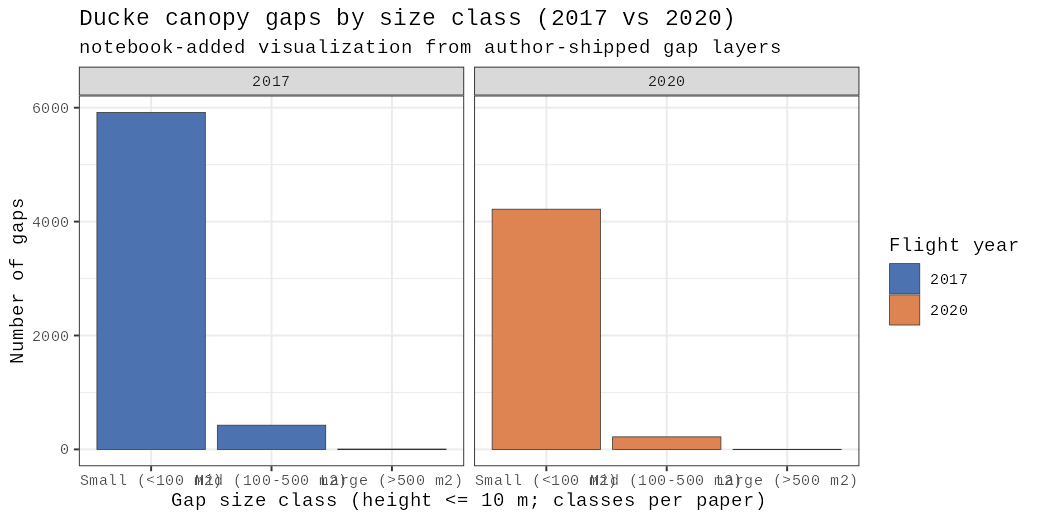

In [ ]:
import subprocess
from IPython.display import Image, display

R_PLOT = r'''
suppressPackageStartupMessages(library(dplyr)); suppressPackageStartupMessages(library(ggplot2))
d17 <- read.csv("/content/ducke_2017gapsClean.csv"); d17$year <- 2017; d17$ano17 <- NULL
d20 <- read.csv("/content/ducke_2020gapsClean.csv"); d20$year <- 2020; d20$ano20 <- NULL
res <- rbind(d17, d20)
res$gapsize <- cut(res$area, c(-Inf, 100, 500, Inf),
                   labels = c("Small (<100 m2)", "Mid (100-500 m2)", "Large (>500 m2)"),
                   right = FALSE)
p <- ggplot(res, aes(gapsize, fill = factor(year))) +
  geom_bar(position = "dodge", color = "grey20", linewidth = 0.2) +
  facet_wrap(~year, nrow = 1) +
  scale_fill_manual(values = c("2017" = "#4C72B0", "2020" = "#DD8452")) +
  labs(title = "Ducke canopy gaps by size class (2017 vs 2020)",
       subtitle = "notebook-added visualization from author-shipped gap layers",
       x = "Gap size class (height <= 10 m; classes per paper)", y = "Number of gaps",
       fill = "Flight year") +
  theme_bw()
ggsave("/content/ducke_gap_size_classes.png", p, width = 8, height = 4, dpi = 130)
cat("plot saved\n")
'''
open("/content/r/plot.R", "w").write(R_PLOT)
proc = subprocess.run(["Rscript", "/content/r/plot.R"], capture_output=True, text=True, timeout=300)
print(proc.stdout)
if proc.returncode != 0:
    raise RuntimeError("Rscript failed:\n" + proc.stderr)
display(Image(filename="/content/ducke_gap_size_classes.png"))

## Results export and summary / 結果のエクスポートと要約

Collects the executed Ducke numbers (frequency table, transition area table, transition probabilities) into one CSV export inside Colab and prints the headline numbers actually computed above. / 実行結果（頻度表・遷移表・遷移確率）をColab内にCSVとしてエクスポートします。

In [ ]:
import pandas as pd

freq = pd.read_csv("/content/ducke_freq_table.csv")
area_t = pd.read_csv("/content/ducke_transition_area.csv")
prob_t = pd.read_csv("/content/ducke_transition_prob.csv")

with open("/content/ducke_results_export.csv", "w") as f:
    f.write("# Ducke gap frequency/size classes (author script 03 logic)\n")
    freq.to_csv(f, index=False)
    f.write("\n# Ducke transition areas m2/ha/yr (author script 04 logic; /1025 ha /3 yr)\n")
    area_t.to_csv(f, index=False)
    f.write("\n# Ducke transition probabilities (notebook-added view)\n")
    prob_t.to_csv(f, index=False)
print("exported: /content/ducke_results_export.csv\n")
print("Gap gap-area rate (gap state -> gap state), m2/ha/yr:")
gg = area_t[(area_t["a_ano17"] == "gap")]
cols = [c for c in gg.columns if c != "a_ano17"]
for c in cols:
    print(f"  gap -> {c}: {gg[c].iloc[0]:.2f}")
print("\nSecond-flight gap area share coming from transitions out of 'gap' vs new gaps:")
print(prob_t.to_string(index=False))

exported: /content/ducke_results_export.csv

Gap gap-area rate (gap state -> gap state), m2/ha/yr:
  gap -> gap: 21.63
  gap -> non.gap: 57.90
  gap -> new gap: 0.00

Second-flight gap area share coming from transitions out of 'gap' vs new gaps:
a_ano17      gap  non.gap  new gap
    gap 0.163492 0.836508 0.000000
non.gap 0.912156 0.000000 0.087844


## Interpretation and validation record / 解釈と検証記録

**What was executed.** The authors' pinned R logic (scripts `01`, `03`, `04` at `Gorgens/dynamics-gap@aae2888`) was run on the authors' shipped Ducke gap/overlay layers, downloaded inside Colab with SHA-256 provenance. Unit consistency (m²) was checked by comparing DBF `area` attributes with recomputed planar geometry areas before analysis.

**Relation to the paper.** The paper reports gap detection at ≤10 m canopy height and ≥10 m², size classes small/mid/large at 100/500 m², and transition analysis by overlapping flight-1 and flight-2 gap layers — all exactly what the executed scripts encode. The paper's χ² statistics quoted in the HTML text concern four-site comparisons (p≈0.26/0.18 for size distribution by flight; p≈0.0011 for transitions across regions); this one-site demonstration yields the Ducke year comparison and Ducke transition matrix, which the HTML text does not quote numerically, so no direct numeric comparison to a published table is claimed. Tables 1–4 of the paper are only accessible via bioRxiv popup links and were not retrieved.

**Limitations / 既知の限界.** One site only; cleaned/overlay layers are author-shipped products (the raw ALS→CHM→gap pipeline in `00-*.R` was not re-run); `raster::area`/`pivottabler` behavior was mapped to `geopandas` planar area and `dplyr` grouped sums (see mapping table); flight intervals are approximate in the paper (Ducke divisor 3 yr taken from author code).

**Provenance.** Paper: bioRxiv 2022.09.03.506473 (Biotropica doi:10.1111/btp.13226). Code: `Gorgens/dynamics-gap` @ `aae2888511781baba3c7a42404ebcf4c731d6a4e`, GPL-3.0 — author scripts inspected on DGX (code-only); all data bytes downloaded in Colab from pinned raw URLs and hash-validated in this notebook. PhenoPaper investigation (run `p-d258d4f4dcf8eb5d33bc8f892b665c15-20260930T231547Z-3806874`, flow `complete_from_fulltext`, reviewStatus unverified) was used as prior research guidance only. / 本NotebookはPhenoPaperの調査結果を参考情報としてのみ使用しています。